# **Linear Regression**


Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**How can we load it in Python using pandas and see the first few rows?**.

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")

## Exploring the Data**

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [5]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [6]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [43]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                     int64
Traffic_Level               int64
Time_of_Day                 int64
Vehicle_Type                int64
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [8]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column.

In [9]:
cat_col = ["Weather",'Traffic_Level','Time_of_Day']
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

<Axes: xlabel='Courier_Experience_yrs', ylabel='Density'>

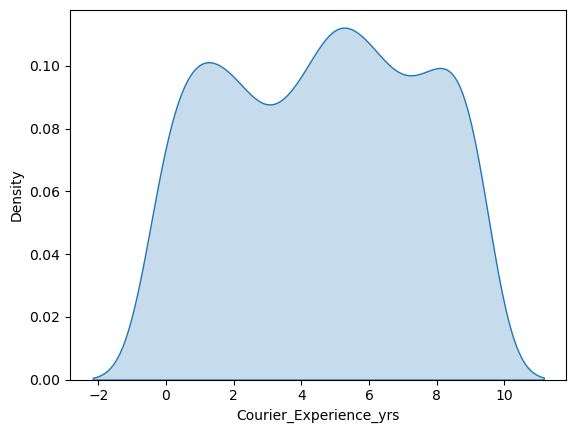

In [11]:
sns.kdeplot(df['Courier_Experience_yrs'],fill = True)

## Visualizing the Data
Visualize the relationships between all pairs of variables in the dataset to see patterns and correlations.

### Mapping Values
Linear Regression works only on numeric data, so we need to convert categorical columns into numbers.

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy = df.copy()
df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

In [13]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


In [14]:
df_copy

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [15]:
cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']

In [16]:
df_dummies = pd.get_dummies(df, columns= cols)

In [17]:
df_dummies = df_dummies.astype(int)

In [18]:
 df_dummies.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_0,Weather_1,Weather_2,Weather_3,Weather_4,Traffic_Level_0,Traffic_Level_1,Traffic_Level_2,Time_of_Day_0,Time_of_Day_1,Time_of_Day_2,Time_of_Day_3,Vehicle_Type_0,Vehicle_Type_1,Vehicle_Type_2
0,522,7,12,1,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16,20,2,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9,28,1,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7,5,1,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19,16,5,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


## **Defining Features and Target**

X (features) → known factors (distance, traffic, weather, etc.)

y (target) → what we want to predict (delivery time)


In [19]:
X_encoded = df.drop("Delivery_Time_min", axis=1)  
y_encoded = df["Delivery_Time_min"]    

X_dummies = df_dummies.drop("Delivery_Time_min", axis=1)  
y_dummies = df_dummies["Delivery_Time_min"]    

## Splitting Data into Train and Test Sets**

How can we check how well our model performs on unseen data?
Why do we split the dataset into two parts:

Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the modelbrary.


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


In [21]:
from sklearn.linear_model import LinearRegression


In [22]:
model_encoded = LinearRegression()

In [23]:
model_encoded.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model_encoded.predict(X_test)
from sklearn.metrics import mean_squared_error,r2_score

mean_squared_error(y_test, y_pred)
r2 =r2_score(y_test, y_pred)
adjusted_r2 = 1 - ((1-r2)*(df.shape[0]-1))/(df.shape[0] - df.shape[1]-1)

In [25]:
r2

0.7562844966321256

In [26]:
adjusted_r2

0.7540689011469631

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y_dummies, test_size=0.2, random_state=42)

In [28]:
model_dummies = LinearRegression()

In [29]:
model_dummies.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = model_dummies.predict(X_test)
from sklearn.metrics import mean_squared_error,r2_score

mean_squared_error(y_test, y_pred)
r2 =r2_score(y_test, y_pred)
adjusted_r2 = 1 - ((1-r2)*(df_dummies.shape[0]-1))/(df_dummies.shape[0] - df_dummies.shape[1]-1)

## Training the Linear Regression Model**


In [31]:
r2

0.8184688733014351

In [32]:
adjusted_r2

0.8147603722452846

## Making Predictions

Use the trained model to predict delivery times for the test data.

## **Evaluating the Model**

Check how accurate your predictions are by calculating the average error, squared error, and R² score.


In [33]:
y_train_pred = model_dummies.predict(X_train)
y_test_pred = model_dummies.predict(X_test)
r2_train = r2_score(y_train,y_train_pred)
r2_test = r2_score(y_test,y_test_pred)

### **Visualizing Predictions**


Create a scatter plot to compare actual vs predicted delivery times and visually check how well the model is performing.


In [34]:
r2_train

0.7607678543714589

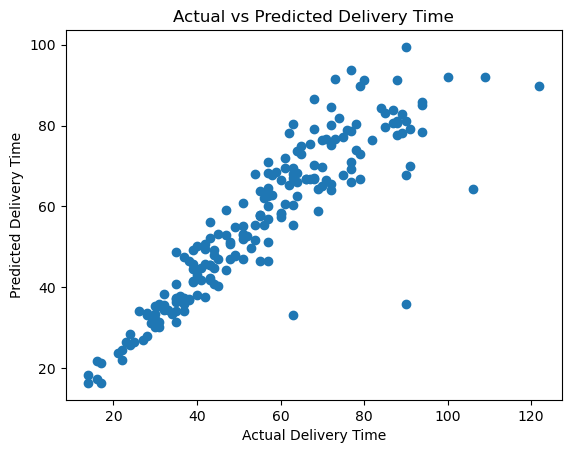

In [35]:
plt.scatter(y_test, y_pred) 
plt.xlabel("Actual Delivery Time") 
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [36]:

r2_test

0.8184688733014351

### Ridge Regression
Train a Ridge regression model on the training data, predict delivery times for the test set, and evaluate its accuracy using MAE, MSE, and R².

In [37]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
ridge = Ridge()
ridge.fit(X_train,y_train)
pred = ridge.predict(X_test)
r2 = r2_score(y_test,pred)
r2

0.8183252656437565

### Lasso Regression
Train a Lasso regression model on your training data, predict delivery times for the test set, and check how accurate the predictions are using MAE, MSE, and R².

In [38]:
model = Lasso()
model.fit(X_train,y_train)
lasso_pred = model.predict(X_test)
r2_score(y_test,lasso_pred)


0.7599507030180991

### Polynomial Regression
Transform your features to include polynomial terms, train a Linear Regression model on them, and calculate the mean squared error to see how well the curved model fits your data.

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)
y_pred = model_poly.predict(X_test_poly)
r2_score(y_test,y_pred)

0.7637391206722706

# Conclusion
-Predicted food delivery times using features like distance, traffic, weather, time, and courier experience.

-Applied Linear Regression for basic predictions.

-Used Ridge and Lasso to reduce overfitting and improve accuracy.

-Explored Polynomial Regression to capture nonlinear relationships.

-Evaluated models with MAE, MSE, and R² to measure performance.

-Demonstrated a real-world application of regression in optimizing delivery operations.

In [40]:
from joblib import dump
dump(model_dummies,'Food_Delivery_Model.joblib')

['Food_Delivery_Model.joblib']